# Import packages

In [96]:
import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import geopandas as gpd

# Load the Sentinel-2 data

In [97]:
filepath_2022 = "../data/raw/S2_composite_2022.tif"

with rasterio.open(filepath_2022) as src:
    print(src.crs)
    sentinel_2022 = src.read()

EPSG:32604


In [98]:
filepath_2024 = "../data/raw/S2_composite_2024.tif"

with rasterio.open(filepath_2024) as src:
    sentinel_2024 = src.read()

# Prepare true color composite of the Sentinel-2 image 2024 as a background map

Text(0.5, 1.0, 'True color composite Sentinel-2 2024')

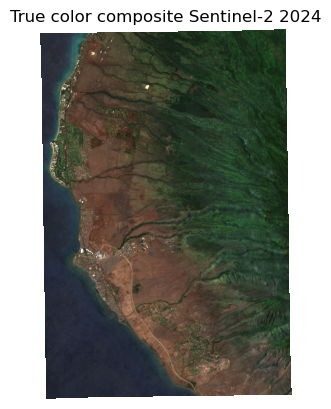

In [99]:
def normalize(composite, vmin=0, vmax=3500): 
    """
    Clips the array to the bounds and scales it to a 0-1 range for display

    Parameters
    ---
    composite: float64
        Satellite image composite

    vmin=0: integer 
        lower bound 

    vmax=3500: integer
        upper bound, depends on the used satellite data

    Returns
    ---
    float64
        Normalized Composite
    """
    # Clip the array to the bounds to eliminate outliers/better contrast and scale it for display because matplotlib needs values from 0 to 1
    
    clipped = np.clip(composite, vmin, vmax)
    return (clipped-vmin)/(vmax-vmin)

# extract and normalize the RGB bands
Red_2024 = normalize(sentinel_2024[3]) 
Green_2024 = normalize(sentinel_2024[2])
Blue_2024 = normalize(sentinel_2024[1])

# stack the bands into true color composite
RGB_2024_normalized = np.dstack((Red_2024, Green_2024, Blue_2024)) 

# plot the true color composit to check
plt.imshow(RGB_2024_normalized)
plt.axis("off")
plt.title("True color composite Sentinel-2 2024")

# Calculate the Normalized Burn Ration (NBR) for Sentinel-2 images

For the calculation: 
***
**NBR** = (NIR-SWIR) / (NIR+SWIR)
***

NIR: Band 8 (Index[7])

SWIR: Band 12 (Index[11])

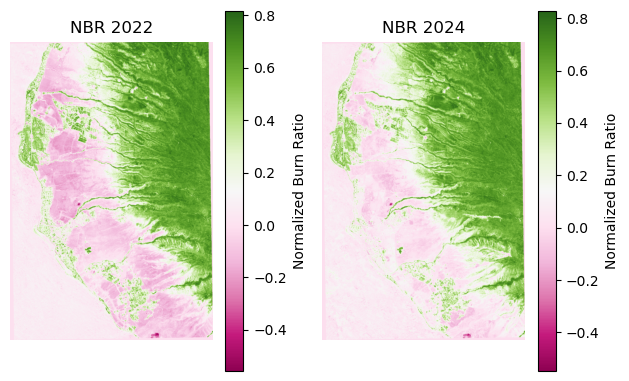

In [100]:
# Function to calculate NBR
def NBR(composite): 
    """
    Calculates the normalized burn ratio and gets rid of the NaNs
    Positive values point to healthy vegetation. Negative values to burned areas

    Parameter
    ---
    composite: float64
        Sentinel-2 composite with 12 spectral bands

    Returns
    ---
    float64
        Normalized burn ratio for each pixel
    """
    # extracting the bands, replacing Nan's with 0 
    NIR = np.nan_to_num(composite[7])
    SWIR = np.nan_to_num(composite[11])
    # avoiding to divide by 0
    denom = (NIR+SWIR)
    NBR = np.divide((NIR-SWIR), denom, out = np.zeros_like(denom), where = denom!=0)
    
    return NBR

# calculate NBR for both composits
NBR_2022 = NBR(sentinel_2022)
NBR_2024 = NBR(sentinel_2024)

# Plot both NBR next to each other to compare visually
fig, (ax1, ax2) = plt.subplots(1,2)
im1 = ax1.imshow(NBR_2022, cmap = "PiYG")
im2 = ax2.imshow(NBR_2024, cmap = "PiYG")
fig.colorbar(im1, ax=ax1, label = "Normalized Burn Ratio", shrink = 0.8)
fig.colorbar(im2, ax=ax2, label = "Normalized Burn Ratio", shrink = 0.8)   

ax1.set_title("NBR 2022")
ax2.set_title("NBR 2024")

ax1.axis("off")
ax2.axis("off")

fig.tight_layout()
fig.savefig("../outputs/NBR_22_24.png", bbox_inches='tight')

## Calculate the difference Normalized Burn Ratio (dNBR)

to evaluate where new area burned because of the wildfire the dNBR has to be calculated

Text(0.5, 1.0, 'Difference NBR')

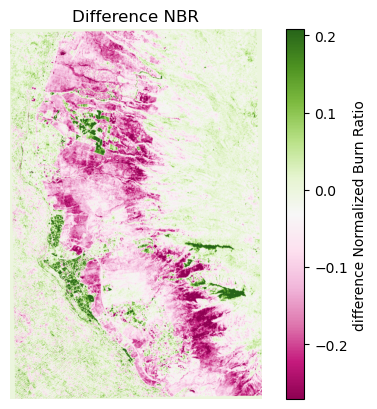

In [101]:
# calculate the difference of the two NBRs (dNBR)
difference_NBR = NBR_2022 - NBR_2024 #positive values point to newly burned area

# plot
plt.imshow(difference_NBR, cmap = "PiYG", vmin=np.nanpercentile(difference_NBR, 1), vmax=np.nanpercentile(difference_NBR, 99))
plt.colorbar(label = "difference Normalized Burn Ratio")
plt.axis("off")
plt.title("Difference NBR")



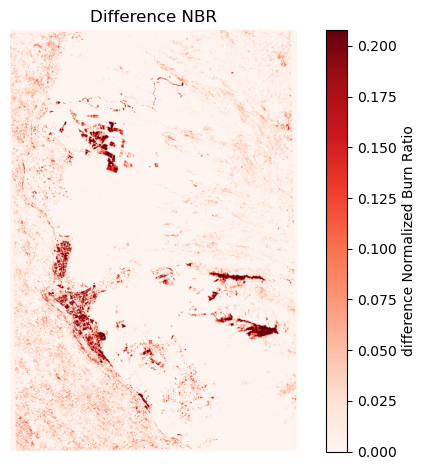

In [102]:
# set the negative values to 0 because for detection of burned areas only the positive values are important
positive_difference = np.clip(difference_NBR, 0, None)

# plot
plt.imshow(positive_difference, cmap = "Reds", vmin = np.nanpercentile(positive_difference, 1), vmax = np.nanpercentile(positive_difference, 99))
plt.colorbar(label = "difference Normalized Burn Ratio")
plt.title("Difference NBR")
plt.axis("off")
plt.tight_layout()

plt.savefig("../outputs/dNBR.png", bbox_inches = 'tight')

## Categorize the severity of the fire using the dNBR

low severity = 0.1 - 0.24 

moderate severity = 0.25 - 0.54

high severity = >=0.55

values from (Rahman et al., 2018)

In [103]:
# creating an array with the same shape as the positive_difference as a template with all NaNs
severity = np.full_like(positive_difference, np.nan) 

# Filling the template with the different cateogories, 
## all the values from the same categories get classified to the same number
severity[(positive_difference >= 0.1) & (positive_difference <= 0.24)] = 1
severity[(positive_difference >= 0.25) & (positive_difference <= 0.54)] = 2
severity[(positive_difference >= 0.55)] = 3


Areas with a dNBR value higher than 0.1 can be considered as burned. That makes it all the pixels that are now classified 1, 2 or 3. The pixels that aren't burned have NaN.

In [104]:
# Calculating total burned area
def changed_area(array, spatial_resolution = 100):
    """
    Calculates the area based on the number of pixels and their spatial resolution. 
    The spatial resolution must be provided in m^2

    Parameter
    ---
    array: float64
        Array with the area of interest

    spatial_resolution: integer
        spatial resolution of the pixels in m^2

    Returns
    ---
    float64
        Area in km^2
    """
    count = np.sum(array)
    area = count * 100
    area_km = area / 1000000
    return area_km

# mask where all pixels considered burned = True
burned = severity >= 1

# calculating the burned area
area_burned = changed_area(burned)

print(f"The total area that burned 2022-2024 amounts to {area_burned:.1f} km\u00b2 calculated with the Normalized Burned Ratio" )


The total area that burned 2022-2024 amounts to 4.7 km² calculated with the Normalized Burned Ratio


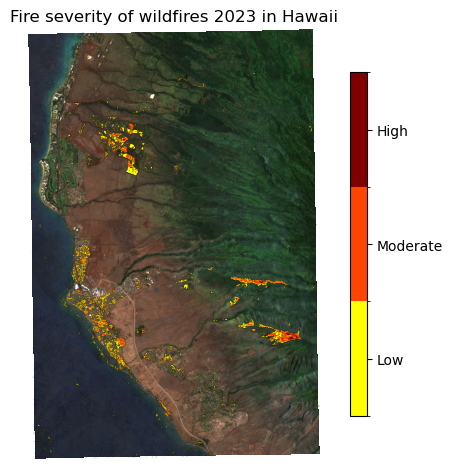

In [105]:
# plot the different categories of fire severity

cmap = colors.ListedColormap([ "yellow", "orangered", "maroon"])
bounds = [ 1, 2, 3, 4] # defines the classes
norm = colors.BoundaryNorm(bounds, cmap.N) # cmap.N gives the number of colors, here 3

plt.imshow(RGB_2024_normalized)
plt.imshow(severity, cmap = cmap, norm = norm)
cbar = plt.colorbar(ticks=[ 1.5, 2.5, 3.5], shrink = 0.8)

cbar.ax.set_yticklabels(["Low", "Moderate", "High"])
plt.title("Fire severity of wildfires 2023 in Hawaii")
plt.axis("off")

plt.tight_layout()

plt.savefig("../outputs/severity_NBR.png", bbox_inches='tight')

# Detect change in the Sentinel-2 images with the cosine similarity

In [106]:
# scale array and get rid of NaNs

## Sentinel-2 data is often stored as 16-bit integers with values roughly ranging from 0 to 10,000.
def scaled(composite):
    """
    Scales the reflectance values from their original range down to [-1, 1] and gets rid of NaNs

    Parameters
    ---
    composite: float64
        Satellite image composite

    Returns
    ---
    float64
        Scaled composite
    """
    scaled = (np.nan_to_num(composite) / 5000) - 1
    return scaled

scaled_sentinel_2022 = scaled(sentinel_2022)
scaled_sentinel_2024 = scaled(sentinel_2024)

# calculate vector lengths
def norm(composite):
    """
    Calculates the vector length in n-dimensional space

    Parameters
    ---
    composite: float64
        Satellite image composite

    Returns
    ---
    float64
        Vector length of the spectral signiture for each pixel in n-dimension
    """
    norm = np.sqrt(np.sum(composite**2, axis = 0)) # axis defines over which dimension the composite get summed up 
    return norm

norm_sentinel_2022 = norm(scaled_sentinel_2022) 
norm_sentinel_2024 = norm(scaled_sentinel_2024)

# Normalize to get Unitvector
## this step makes the calculation for the cosine similarity easier
unit_sentinel_2022 = scaled_sentinel_2022 / norm_sentinel_2022
unit_sentinel_2024 = scaled_sentinel_2024 / norm_sentinel_2024


In [107]:
# test if calculation of unit vectors worked
unit_test = np.abs(norm(unit_sentinel_2022))

print(unit_test)

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


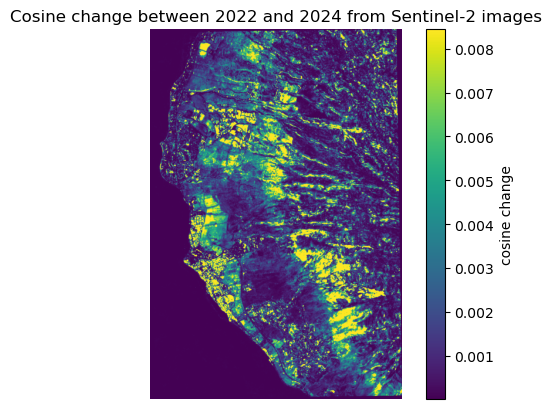

In [108]:
# calculate cosine similarity
cosine_similarity_sentinel = np.sum(unit_sentinel_2022 * unit_sentinel_2024, axis = 0)

# calculate cosine change
cosine_change_sentinel = 1 - cosine_similarity_sentinel

# plot
plt.imshow(cosine_change_sentinel, vmin=np.nanpercentile(cosine_change_sentinel,5), vmax=np.nanpercentile(cosine_change_sentinel,95))
plt.colorbar(label = "cosine change")

plt.axis("off")
plt.title("Cosine change between 2022 and 2024 from Sentinel-2 images")
plt.savefig("../outputs/cosine_change_sent.png", bbox_inches='tight')

## Quantifying the change

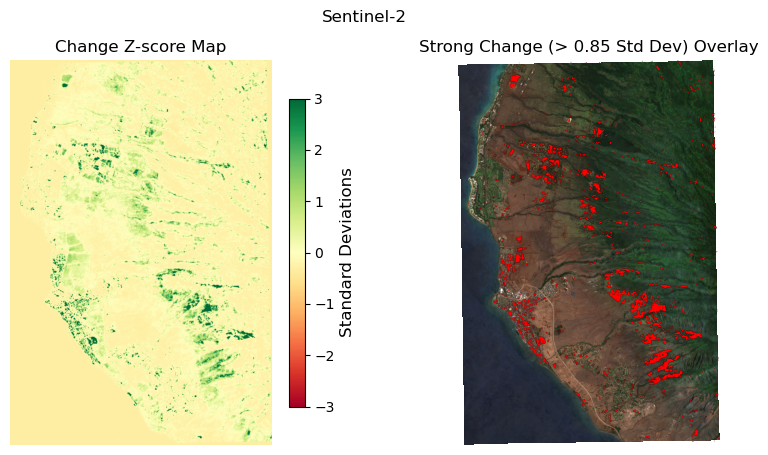

In [109]:
mean_val_sentinel = np.nanmean(cosine_change_sentinel)
std_val_sentinel = np.nanstd(cosine_change_sentinel)

# calculate z-score
z_score_sentinel = (cosine_change_sentinel - mean_val_sentinel) / std_val_sentinel

# define strong change threshold and create a mask where z-score is greater than threshold
## setting the threshold at the 95-percentile of the z-score, everything above that will be cosindered strong change
threshold_sentinel = np.percentile(z_score_sentinel, [95]).item() # .item() changes NumPy-Array to a float
strong_change_mask_sentinel = z_score_sentinel > threshold_sentinel

# plot the strong change and z-score
plot_mask_sentinel = np.where(strong_change_mask_sentinel, 1, np.nan) # NaN is better than 0 because area gets transparent insted of colored

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
im1 = ax1.imshow(z_score_sentinel, cmap = "RdYlGn", vmin = -3, vmax = 3)
ax1.set_title("Change Z-score Map")
ax1.axis("off")
cbar = fig.colorbar(im1, ax = ax1, shrink = 0.8)
cbar.set_label("Standard Deviations", fontsize = 12)

im2 = ax2.imshow(RGB_2024_normalized)
ax2.imshow(plot_mask_sentinel,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_sentinel:.2f} Std Dev) Overlay')
ax2.axis("off")
fig.suptitle("Sentinel-2")

fig.savefig("../outputs/z_score_and_strongchange_sent.png", bbox_inches='tight')

In [110]:
# calculate area with strong change
area_strong_change_sentinel = changed_area(strong_change_mask_sentinel)
print(f"The total area that underwent a strong change from 2022-2024 amounts to {area_strong_change_sentinel:.1f} km\u00b2 calculated from the Sentinel-2 images" )

The total area that underwent a strong change from 2022-2024 amounts to 8.3 km² calculated from the Sentinel-2 images


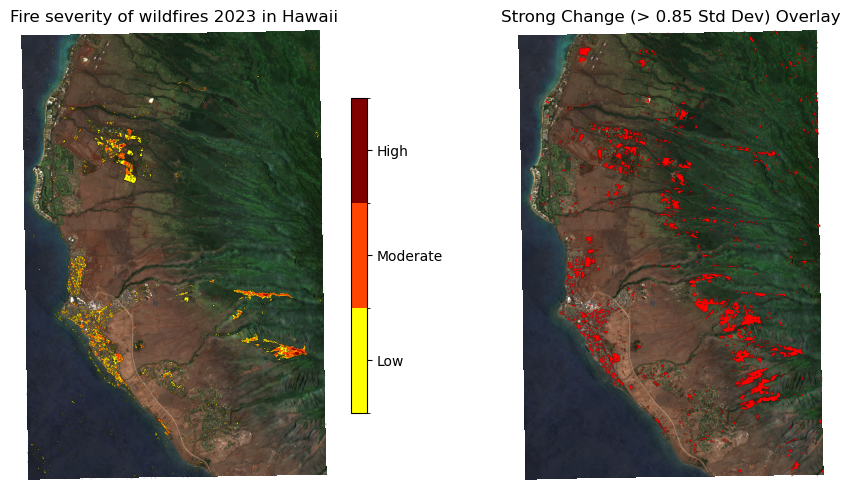

In [111]:
# plot the  cosine change and dNBR next to each other

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
cmap_1 = colors.ListedColormap(["yellow", "orangered", "maroon"])
bounds_1 = [ 1, 2, 3,4]
norm_1 = colors.BoundaryNorm(bounds_1, cmap_1.N)

ax1.imshow(RGB_2024_normalized)
im1 = ax1.imshow(severity, cmap = cmap_1, norm = norm_1)
cbar1 = fig.colorbar(im1,ticks = [1.5, 2.5, 3.5], shrink = 0.7, location = "right")

cbar1.ax.set_yticklabels(["Low", "Moderate", "High"])

ax1.set_title("Fire severity of wildfires 2023 in Hawaii")
ax1.axis("off")

ax2.imshow(RGB_2024_normalized)
ax2.imshow(plot_mask_sentinel,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_sentinel:.2f} Std Dev) Overlay')
ax2.axis("off")

fig.tight_layout()
fig.savefig("../outputs/NBR_strongchange_sent.png", bbox_inches='tight')

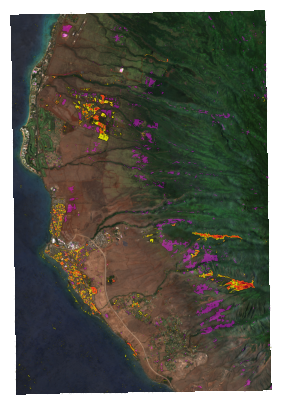

In [112]:
# plot the strong change area and overlay the burned area for visual comparison 
fig, ax = plt.subplots(figsize = (10, 5))
ax.imshow(RGB_2024_normalized)
ax.imshow(plot_mask_sentinel, cmap = "cool_r", alpha = 0.4)
ax.imshow(severity, cmap=cmap_1, norm = norm_1, alpha = 0.8)
ax.axis("off")

fig.savefig("../outputs/NBR_strongchange_overlay.png", bbox_inches='tight')

# Detect change in the AlphaEarth embeddings with the cosine similarity

In [113]:
filepath_AE_2022 = "../data/raw/AEF_embedding_2022.tif"
with rasterio.open(filepath_AE_2022) as src:
    print(src.crs)
    AE_2022 = src.read()
    print(AE_2022.shape)

filepath_AE_2024 = "../data/raw/AEF_embedding_2024.tif"
with rasterio.open(filepath_AE_2024) as src:
    AE_2024 = src.read()
    print(AE_2024.shape)
   



EPSG:32604
(64, 1566, 1064)
(64, 1566, 1064)


In [114]:
# check the range of values
print(np.nanmax(AE_2024))
print(np.nanmin(AE_2024))

print(np.nanmax(AE_2022))
print(np.nanmin(AE_2022))

## values are already scaled from [-0.5, 0.5], therefore the scaling step isn't necessary


0.46560553633217994
-0.46560553633217994
0.47637062668204533
-0.48725874663590923


In [115]:
# replace NaN with 0
AE_2024 = np.nan_to_num(AE_2024)
AE_2022 = np.nan_to_num(AE_2022)

# calculate vector length
norm_AE_2022 = norm(AE_2022)
norm_AE_2024 = norm(AE_2024)

# mask pixels where vector length is 0 as invalid
invalid_AE = (norm_AE_2022 == 0) | (norm_AE_2024 == 0)

# to avoid dividing by zero
norm_AE_2022[invalid_AE] = 1
norm_AE_2024[invalid_AE] = 1

# normalize to unitvector
unit_AE_2022 = AE_2022 / norm_AE_2022
unit_AE_2024 = AE_2024 / norm_AE_2024


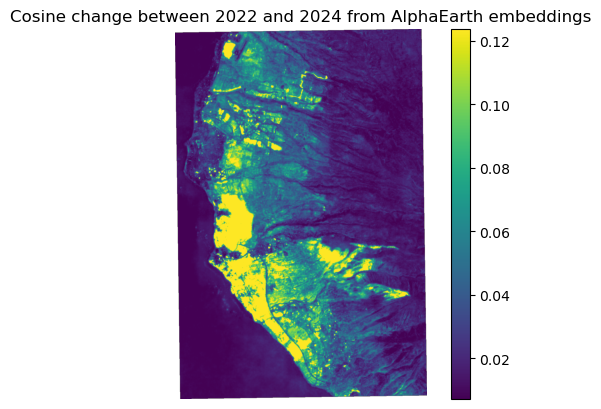

In [116]:
# calculate cosine similarity
cosine_similarity_AE = np.sum(unit_AE_2022 * unit_AE_2024, axis = 0)

# calculate cosine change
cosine_change_AE = 1 - cosine_similarity_AE

# remove invalid border/no-data pixels (where vector length is 0)
cosine_change_AE[invalid_AE] = np.nan

# plot
plt.imshow(cosine_change_AE, vmin = np.nanpercentile(cosine_change_AE, 5), vmax = np.nanpercentile(cosine_change_AE, 95))
plt.colorbar()
plt.axis("off")
plt.title("Cosine change between 2022 and 2024 from AlphaEarth embeddings")
plt.savefig("../outputs/cosine_change_AE.png", bbox_inches='tight')

## Quantifying the change

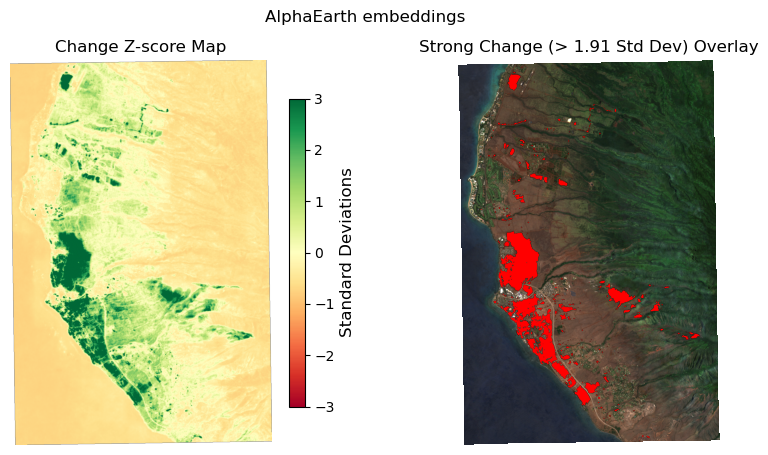

In [117]:
mean_val_AE = np.nanmean(cosine_change_AE)
std_val_AE = np.nanstd(cosine_change_AE)

# calculate z-score
z_score_AE = (cosine_change_AE - mean_val_AE) / std_val_AE

# define strong change threshold and create a mask where z-score is greater than threshold
## setting the threshold at the 95-percentile of the z-score, everything above that will be cosindered strong change
threshold_AE = np.nanpercentile(z_score_AE, [95]).item() 

strong_change_AE = z_score_AE > threshold_AE

# plot
plot_mask_AE = np.where(strong_change_AE, 1, np.nan) #the NaN instead of 0 to make it transparent for plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
im1 = ax1.imshow(z_score_AE, cmap = "RdYlGn", vmin = -3, vmax = 3)
ax1.set_title("Change Z-score Map")
ax1.axis("off")
cbar = fig.colorbar(im1, ax = ax1, shrink = 0.8)
cbar.set_label("Standard Deviations", fontsize = 12)


im2 = ax2.imshow(RGB_2024_normalized)
ax2.imshow(plot_mask_AE ,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_AE:.2f} Std Dev) Overlay')
ax2.axis("off")
fig.suptitle("AlphaEarth embeddings")

fig.savefig("../outputs/z_score_and_strongchange_AE.png", bbox_inches='tight')

In [118]:
# calculate the strong changed area
area_AE = changed_area(strong_change_AE)
print(f"The total area that underwent a strong change from 2022-2024 amounts to {area_AE:.1f} km\u00b2 calculated with the AE embedded pixel" )

The total area that underwent a strong change from 2022-2024 amounts to 8.1 km² calculated with the AE embedded pixel


# Compare the AlphaEarth and Sentinel-2 outputs visually

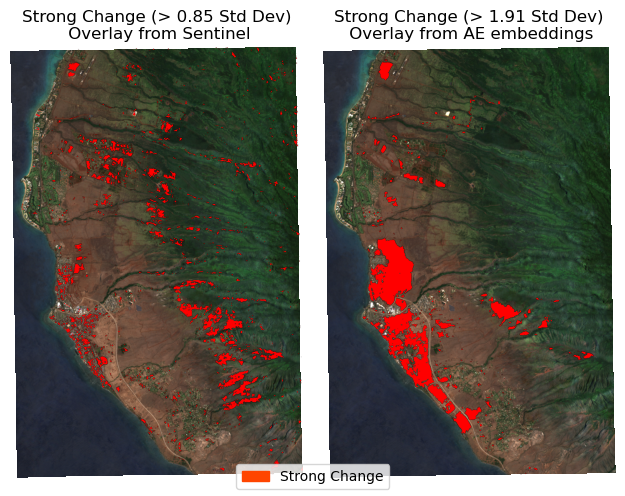

In [119]:
# plot the cosine change from Sentinel-2 and AlphaEarth next to each other
fig, (ax1, ax2) = plt.subplots(1, 2)

# sentinel-2
im1 = ax1.imshow(RGB_2024_normalized)
ax1.imshow(plot_mask_sentinel,cmap = "autumn")
ax1.set_title(f"Strong Change (> {threshold_sentinel:.2f} Std Dev)\n Overlay from Sentinel")
ax1.axis("off")

# AlphaEarth
im2 = ax2.imshow(RGB_2024_normalized)
ax2.imshow(plot_mask_AE,cmap = "autumn")
ax2.set_title(f'Strong Change (> {threshold_AE:.2f} Std Dev)\n Overlay from AE embeddings')
ax2.axis("off")

fig.tight_layout()

legend_patch = mpatches.Patch(color = "orangered", label = "Strong Change")
fig.legend(handles = [legend_patch],
           loc = "lower center",
           ncol = 1)

fig.savefig("../outputs/strongchange_sent_AE.png", bbox_inches='tight')